In [1]:
import scvelo as scv
import scanpy as sc
#import scFates as scf
import numpy as np
import pandas as pd
import anndata as ad
import os

In [4]:
scv.settings.verbosity = 3
scv.settings.set_figure_params('scvelo', facecolor='white', dpi=100, frameon=False)
#cr.settings.verbosity = 2

In [5]:
# Load loom files from two conditions
ctrl = scv.read('P29402_ssri_control.loom', cache=True)
sert = scv.read('P29402_sertraline.loom', cache=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
barcodes = [bc.split(':')[1] for bc in ctrl.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_1' for bc in barcodes]
ctrl.obs.index = barcodes



In [7]:
barcodes1 = [bc.split(':')[1] for bc in sert.obs.index.tolist()]
barcodes1 = [bc[0:len(bc)-1] + '_2' for bc in barcodes1]
sert.obs.index = barcodes1

In [8]:
ctrl.var_names_make_unique()
sert.var_names_make_unique()

In [10]:
sert

AnnData object with n_obs × n_vars = 7662 × 36601
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [11]:
# Concatenate the two conditions
adata = ctrl.concatenate(sert, batch_key='Condition')

In [12]:
adata

AnnData object with n_obs × n_vars = 17390 × 36601
    obs: 'Condition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [14]:
adata.write('SSRI_loom_concatenated.h5ad')

In [15]:
# Load h5ad file with precomputed embedding and metadata
ssri = ad.read_h5ad('SSRI.h5ad')

In [19]:
ssri.obs_names

Index(['CCAATTTCAACTAGAA-1', 'AGACTCACACATTCTT-1', 'TCAGTTTTCGCCTTGT-1',
       'TCCTTCTCAGTAGGAC-1', 'ATACTTCTCCACCTGT-1', 'CTCAATTCAGGTTTAC-1',
       'CTACATTTCGCAATTG-1', 'AACAAAGGTAAGTAGT-1', 'ATACCTTTCTTGGTCC-1',
       'TTTCACACACTACCGG-1',
       ...
       'CCGTAGGTCGGTTGTA-2', 'ATACCGACATCATGAC-2', 'CAGGTATGTACTGAGG-2',
       'TAGGGTTGTAGACTGG-2', 'GGGATGAGTCAGGTAG-2', 'TTGGATGAGTTCCGGC-2',
       'CGATGGCGTATGTCAC-2', 'AGAGAATCATCGTTCC-2', 'ACGGAAGCAAGACAAT-2',
       'TCACTCGAGCAAGCCA-2'],
      dtype='object', length=10982)

In [26]:
import anndata
import pandas as pd

# Function to convert obs_names to barcodes
def convert_to_barcode(obs_name):
    # If the obs_name contains an underscore, process it normally
    if '_' in obs_name:
        name_parts = obs_name.split('_')
        
        if len(name_parts) < 2:
            print(f"Skipping invalid format (missing second part): {obs_name}")
            return None
        
        sequence = name_parts[0]  # e.g., CCGTAGGTCGGTTGTA
        sample_id = name_parts[1]  # e.g., 2-1 or 1-0

        # Replace the hyphen (-) with an underscore (_) in the sample_id
        sample_id = sample_id.replace('-', '_')

        if sample_id.endswith('1'):
            new_sample_id = sample_id + '-0'
        elif sample_id.endswith('2'):
            new_sample_id = sample_id + '-1'
        else:
            new_sample_id = sample_id  # If not 1 or 2, leave it as is
        
        barcode = sequence + '_' + new_sample_id
        return barcode

    # If the obs_name contains no underscore, process it differently (split by hyphen)
    elif '-' in obs_name:
        # Split by the hyphen and process
        name_parts = obs_name.split('-')
        
        if len(name_parts) < 2:
            print(f"Skipping invalid format (missing second part after '-'): {obs_name}")
            return None
        
        sequence = name_parts[0]  # e.g., TCCTCGAAGACGTCCC
        sample_id = name_parts[1]  # e.g., 1 or 2
        
        # Format the sample_id as required (append '-0' for '1' and '-1' for '2')
        if sample_id == '1':
            new_sample_id = sample_id + '-0'
        elif sample_id == '2':
            new_sample_id = sample_id + '-1'
        else:
            new_sample_id = sample_id  # If not 1 or 2, leave it as is
        
        barcode = sequence + '_' + new_sample_id
        return barcode

    # If the obs_name does not match either pattern, return None or leave it as is
    print(f"Skipping invalid format: {obs_name}")
    return None


# Apply the function to all obs_names and save the result as a new column in adata.obs
ssri.obs['loom_barcode'] = ssri.obs_names.map(convert_to_barcode)

# Now the 'loom_barcode' column is added to adata.obs
print(ssri.obs[['loom_barcode']].head())

# Optionally, save the updated AnnData object back to a file
# ssri.write('updated_data_with_barcodes.h5ad')


                            loom_barcode
CCAATTTCAACTAGAA-1  CCAATTTCAACTAGAA_1-0
AGACTCACACATTCTT-1  AGACTCACACATTCTT_1-0
TCAGTTTTCGCCTTGT-1  TCAGTTTTCGCCTTGT_1-0
TCCTTCTCAGTAGGAC-1  TCCTTCTCAGTAGGAC_1-0
ATACTTCTCCACCTGT-1  ATACTTCTCCACCTGT_1-0


In [18]:
adata.obs_names

Index(['AAAGGATGTGATAGAT_1-0', 'AAACGCTTCGGCATAT_1-0', 'AAACCCAGTCAATGGG_1-0',
       'AAAGTGAGTACCTAAC_1-0', 'AAAGGGCAGTCATCCA_1-0', 'AAACGAACAGCACCCA_1-0',
       'AAAGTGAAGTTGAATG_1-0', 'AAAGTGATCGCAATGT_1-0', 'AAAGGGCAGACTCTTG_1-0',
       'AAAGGTATCTCGGGAC_1-0',
       ...
       'TTTGACTCATTGAAAG_2-1', 'TTTGACTAGCGTTAGG_2-1', 'TTTGTTGAGGTACAGC_2-1',
       'TTTGATCTCTCATTGT_2-1', 'TTTGACTAGCGTGTTT_2-1', 'TTTGGTTAGGCGACAT_2-1',
       'TTTCCTCTCTGTTCAT_2-1', 'TTTGTTGAGTGAGCCA_2-1', 'TTTGATCTCTCCTGAC_2-1',
       'TTTGTTGAGATAGCAT_2-1'],
      dtype='object', length=17390)

In [27]:
# Retain cells in adata that are present in adata_h5ad
adata1 = adata[ssri.obs['loom_barcode']]

In [29]:
ssri1 = ssri

In [31]:
ssri1.obs_names = ssri1.obs['loom_barcode']

In [28]:
adata1

View of AnnData object with n_obs × n_vars = 10982 × 36601
    obs: 'Condition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [32]:
# Transfer the precomputed embedding and metadata to the concatenated data
adata1.obsm = ssri1.obsm
adata1.obs = ssri1.obs

In [34]:
del ctrl
del sert

In [35]:
# Process scvelo analysis
scv.pp.filter_and_normalize(adata1)

Normalized count data: X, spliced, unspliced.


/Users/susmita.malwade/miniforge3/envs/scFates/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.


In [37]:
sc.pp.pca(adata1)
sc.pp.neighbors(adata1, n_pcs=30, n_neighbors=30)

In [38]:
scv.pp.moments(adata1)
scv.tl.velocity(adata1)
scv.tl.velocity_graph(adata1)

computing moments based on connectivities
    finished (0:00:21) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/Users/susmita.malwade/miniforge3/envs/scFates/lib/python3.12/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:02:08) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/8 cores)


  0%|          | 0/10982 [00:00<?, ?cells/s]

    finished (0:07:04) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


/Users/susmita.malwade/miniforge3/envs/scFates/lib/python3.12/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


saving figure to file ./figures/scvelo_SSRI_velocity.pdf


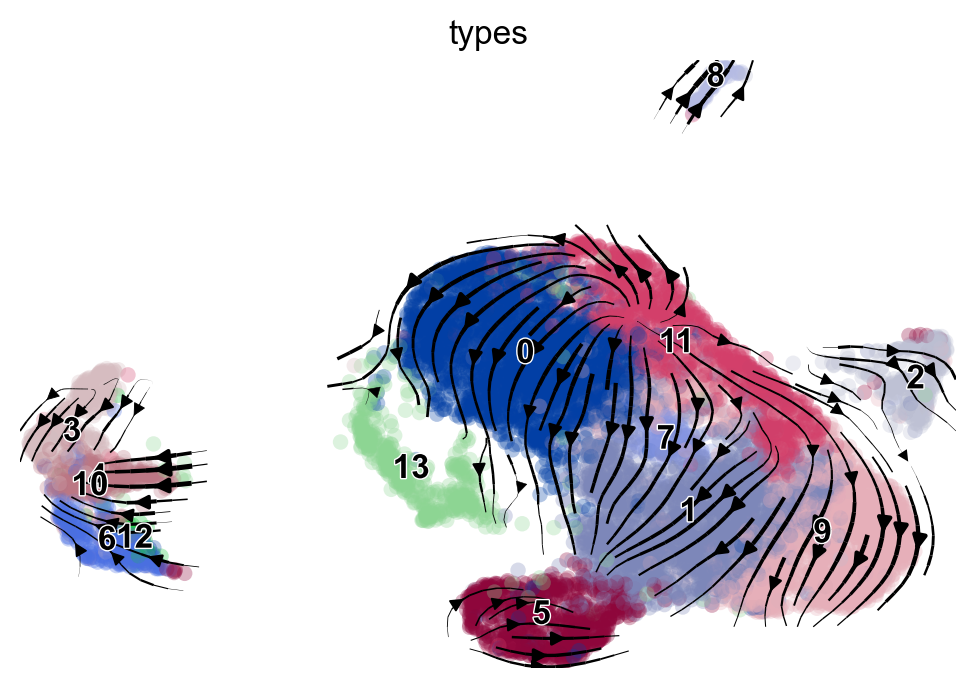

In [45]:
# Plot the velocity embedding
scv.pl.velocity_embedding_stream(adata1, basis='umap', color='types', save='SSRI_velocity.pdf')

In [41]:
adata1

AnnData object with n_obs × n_vars = 10982 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'log10GenesPerUMI', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'assignment', 'multiplet_status', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'SCT_snn_res.0.6', 'SCT_snn_res.0.8', 'seurat_clusters', 'doublet_prob', 'celltype', 'replicate', 'SCT_snn_res.0.5', 'types', 'barcode', 'loom_barcode', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'types_colors'
    obsm: 'X_umap', 'X_pca', 'velocity_umap'
    varm: 'PCs'
    

In [44]:
adata1.write('SSRI_velocity_embedded.h5ad')

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


/Users/susmita.malwade/miniforge3/envs/scFates/lib/python3.12/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


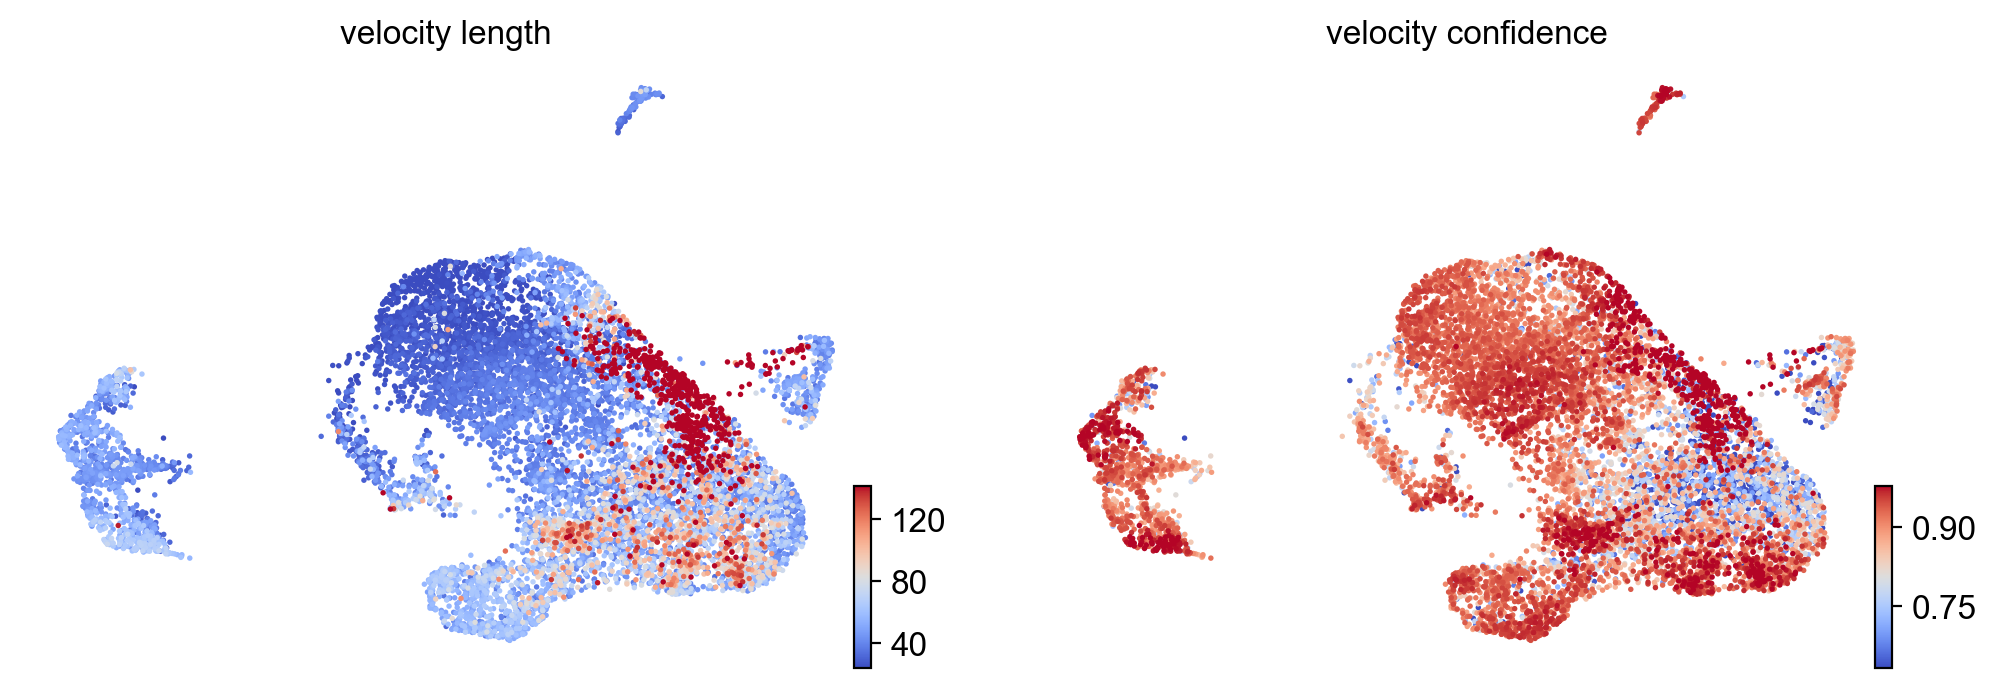

In [46]:
scv.tl.velocity_confidence(adata1)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata1, c=keys, cmap='coolwarm', perc=[5, 95])

recovering dynamics (using 1/8 cores)


  0%|          | 0/3464 [00:00<?, ?gene/s]

    finished (1:40:02) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:03:44) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/8 cores)


  0%|          | 0/10982 [00:00<?, ?cells/s]

    finished (0:02:50) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:01:31) --> added 
    'latent_time', shared time (adata.obs)


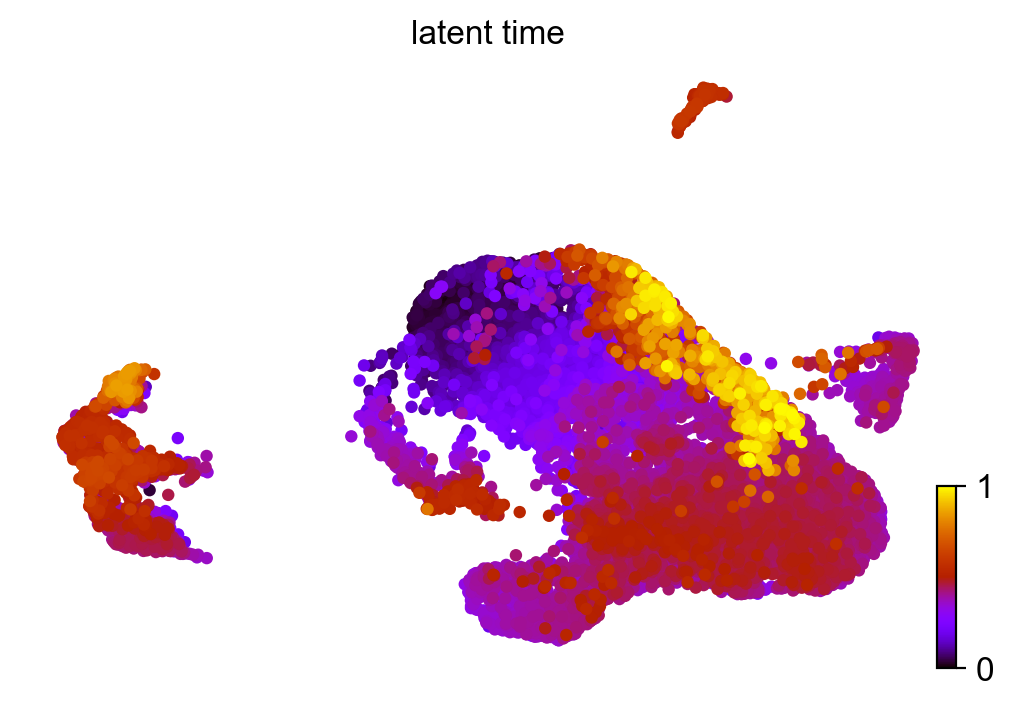

In [48]:
scv.tl.recover_dynamics(adata1)
scv.tl.velocity(adata1, mode='dynamical')
scv.tl.velocity_graph(adata1)
scv.tl.latent_time(adata1)
scv.pl.scatter(adata1, color='latent_time', color_map='gnuplot', size=80)

In [49]:
adata1

AnnData object with n_obs × n_vars = 10982 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'log10GenesPerUMI', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'assignment', 'multiplet_status', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'SCT_snn_res.0.6', 'SCT_snn_res.0.8', 'seurat_clusters', 'doublet_prob', 'celltype', 'replicate', 'SCT_snn_res.0.5', 'types', 'barcode', 'loom_barcode', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamm

In [50]:
os.getcwd()

'/Volumes/projects/C3_Sellgren_lab/Lab Members/Susmita/Internal data/CMV & SSRI/scRNAseq/SSRI/SSRI'

In [51]:
adata1.write('SSRI_velocity_embedded.h5ad')

In [2]:
adata = sc.read_h5ad('SSRI.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 10982 × 31129
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'log10GenesPerUMI', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'assignment', 'multiplet_status', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'SCT_snn_res.0.6', 'SCT_snn_res.0.8', 'seurat_clusters', 'doublet_prob', 'celltype', 'replicate', 'SCT_snn_res.0.5', 'types', 'barcode'
    var: 'features'
    obsm: 'X_umap'